In [4]:
# Checkout www.pygimli.org for more examples


# ERT field data with topography

Simple example of data measured over a slagdump demonstrating:

- 2D inversion with topography
- geometric factor generation
- topography effect

The data is the profile 11 already shown by Günther et al. (2006, Fig. 11).


In [5]:
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert

Get some example data with, typically by a call like
data = ert.load("filename.dat")
that supports various file formats



In [6]:
data = pg.getExampleData('ert/slagdump.ohm', verbose=True)
print(data)

17/03/26 - 22:24:27 - pyGIMLi - INFO - Looking for ert/slagdump.ohm in gimli-org/example-data/
17/03/26 - 22:24:27 - pyGIMLi - INFO - File already exists: /home/pablo/.cache/pygimli/example-data/gimli-org/example-data/master/ert/slagdump.ohm
17/03/26 - 22:24:27 - pyGIMLi - INFO - Reading /home/pablo/.cache/pygimli/example-data/gimli-org/example-data/master/ert/slagdump.ohm (<class 'pgcore._pygimli_.DataContainerERT'>)


Data: Sensors: 38 data: 222, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


Let us first have a look at the topography contained in the data



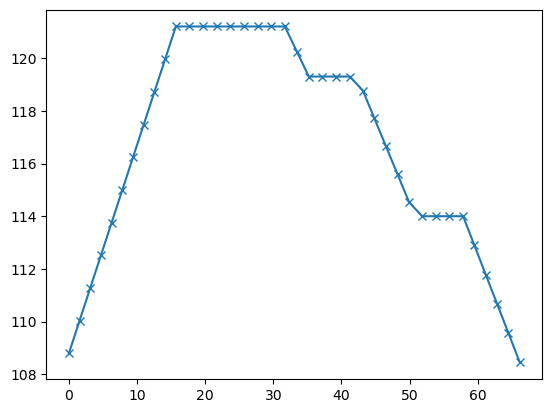

In [7]:
plt.plot(pg.x(data), pg.z(data), 'x-')

The data file does not contain geometric factors (token field 'k'),
so we create them based on the given topography.



In [8]:
k0 = ert.createGeometricFactors(data)  # the analytical one
data['k'] = ert.createGeometricFactors(data, numerical=True)

17/03/26 - 22:24:27 - pyGIMLi - INFO - Cache /home/pablo/miniforge3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 1): /home/pablo/.cache/pygimli/7291408453676423785
17/03/26 - 22:24:27 - pyGIMLi - INFO - Cache /home/pablo/miniforge3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (3.7s x 1): /home/pablo/.cache/pygimli/465573005011586612


It might be interesting to see the topography effect, i.e the ratio between
the numerically computed geometry factor and the analytical formula after
Rücker et al. (2006). We display it using a colormap with neutral white.



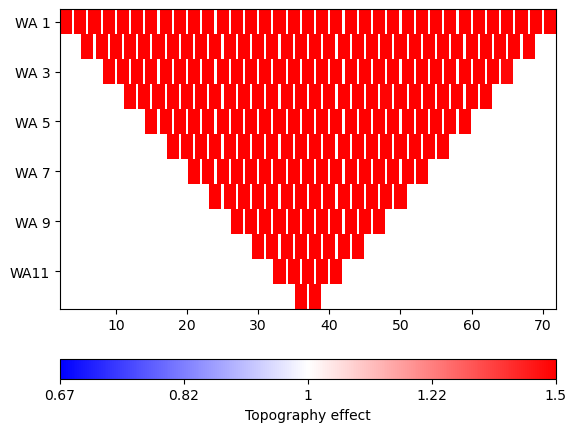

In [9]:
_ = ert.showData(data, vals=k0/ data['k'], label='Topography effect',
                 cMin=2/3, cMax=3/2, logScale=True, cMap="bwr")

We can now compute the apparent resistivity and display it, once with the
wrong analytical formula and once with the numerical values in data['k']



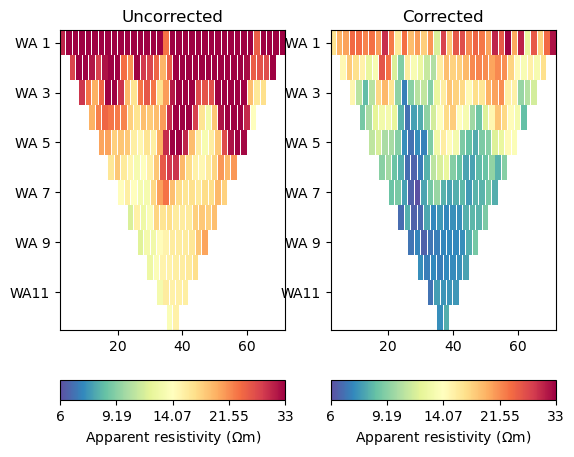

In [10]:
data['rhoa'] = data['r'] * data['k']
kw = dict(cMin=6, cMax=33)
fig, ax = plt.subplots(ncols=2)
data.show(data['r']*k0, ax=ax[0], **kw);
data.show(ax=ax[1], **kw)
ax[0].set_title('Uncorrected')
ax[1].set_title('Corrected');

The data container does not necessarily contain data errors data errors
(token field 'err'), requiring us to enter data errors. We can let the
manager guess some defaults for us automaticly or set them manually



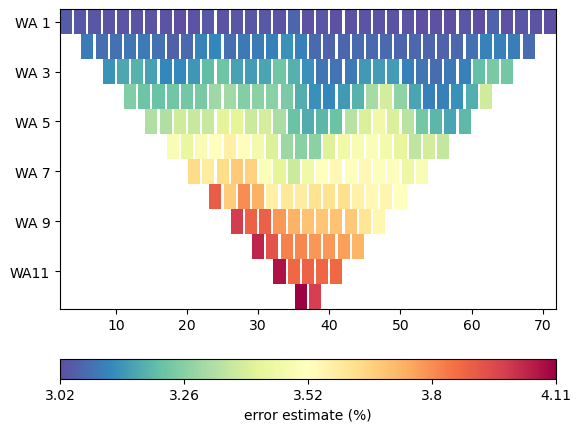

In [11]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)
# which internally calls
# data['err'] = ert.estimateError(data, ...)  # can also set manually
_ = data.show(data['err']*100, label='error estimate (%)')

We initialize the ERTManager for further steps and eventually inversion.



In [12]:
mgr = ert.ERTManager(data)

Now the data have all necessary fields ('rhoa', 'err' and 'k') so we can run
the inversion. The inversion mesh will be created with some optional values
for the parametric mesh generation.




17/03/26 - 22:24:28 - pyGIMLi - INFO - Found 2 regions.
17/03/26 - 22:24:28 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
17/03/26 - 22:24:28 - pyGIMLi - INFO - Found 2 regions.
17/03/26 - 22:24:28 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
17/03/26 - 22:24:28 - pyGIMLi - INFO - Creating forward mesh from region infos.
17/03/26 - 22:24:28 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
17/03/26 - 22:24:29 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3406 Cells: 6492 Boundaries: 5028
17/03/26 - 22:24:29 - pyGIMLi - INFO - Use median(data values)=10.648608361317017


Constructing Delaunay triangulation by divide-and-conquer method.
Delaunay milliseconds:  0
Recovering segments in Delaunay triangulation.
Segment milliseconds:  0
Removing unwanted triangles.
Spreading regional attributes and area constraints.
Hole milliseconds:  0
Adding Steiner points to enforce quality.
Quality milliseconds:  1

Writing vertices.
Writing triangles.
Writing segments.
Writing edges.

Output milliseconds:  0
Total running milliseconds:  1

Statistics:

  Input vertices: 120
  Input segments: 121
  Input holes: 0

  Mesh vertices: 892
  Mesh triangles: 1623
  Mesh edges: 2514
  Mesh exterior boundary edges: 159
  Mesh interior boundary edges: 38
  Mesh subsegments (constrained edges): 197

min/max(dweight) = 24.3573/33.1265


17/03/26 - 22:24:29 - pyGIMLi - INFO - Created startmodel from forward operator:1029, min/max=10.648608/10.648608
17/03/26 - 22:24:29 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x7a7618b34810>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.07/33.48
min/max (error): 3.02%/4.11%
min/max (start model): 10.65/10.65
--------------------------------------------------------------------------------
Calculating response for model: min = 10.6486 max = 10.6486
Allocating memory for primary potential...... 0.0067742

No primary potential for secondary field calculation with topography.
Creating P2-Primmesh:		Nodes: 13303	Cells: 6492	Boundaries: 9897
ModellingBase::setMesh() copying new mesh ... Found topography for surface=114.039 : 113.853
Found datafile: 38 electrodes
Found: 38 node-electrodes
rMin = 0.999991, rMax = 132.345
NGauLeg + NGauLag for inverse Fouriertransformation: 12 + 4
Found non-Neumann domain
0.0280877 s
FOP updating mesh dependencies ... 2.71e-06 s
Forward: time: 8.65598s
Interpolating to secondary

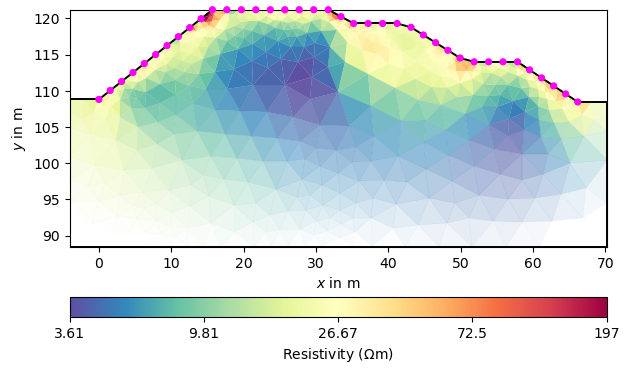

In [13]:
mod = mgr.invert(data, lam=10, verbose=True,
                 paraDX=0.3, paraMaxCellSize=10, paraDepth=20, quality=33.6)
ax, cb = mgr.showResult()

We can view the resulting model in the usual way.



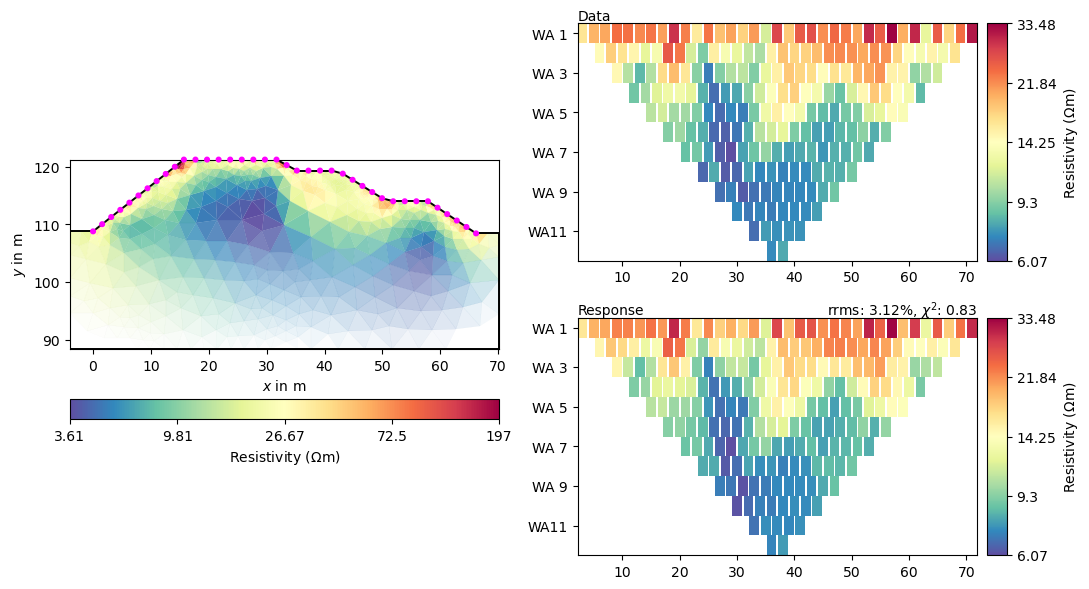

In [14]:
_ = mgr.showResultAndFit()
# np.testing.assert_approx_equal(ert.inv.chi2(), 1.10883, significant=3)

Or just plot the model only using your own options.



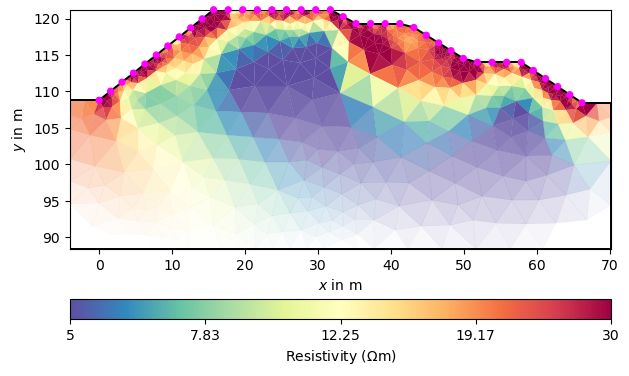

In [15]:
ax, cb = mgr.showResult(mod, cMin=5, cMax=30, cMap="Spectral_r", logScale=True)